# Macro Data Alignment: Multi-Frequency Integration

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.3 (Fundamentals Across the Asset-Class Spectrum)

## Purpose

Macroeconomic data presents unique challenges for trading models: different release cadences
(monthly CPI, weekly claims, quarterly GDP), revision histories, and the critical requirement
of point-in-time correctness. This notebook demonstrates how to align multi-frequency macro
data for daily trading models using pre-downloaded FRED data.

## Learning Objectives

After completing this notebook, you will be able to:
- Load and explore pre-downloaded FRED macro data
- Understand release lag and its impact on point-in-time correctness
- Align multi-frequency data to a common daily timeline
- Create stationary macro features (z-scores, regimes, momentum)
- Use ALFRED vintage data for true point-in-time backtesting

## Prerequisites

- Run `06_fred_macro_eda` first for basic FRED data orientation
- Run the macro data download script: `python data/macro/download.py`

## Cross-References

- **Upstream**: `06_fred_macro_eda` (basic FRED intro), `data/macro/download.py`
- **Downstream**: Chapter 8 `macro_regime_features.py`
- **Related**: [`09_onchain_fundamentals`](09_onchain_fundamentals.ipynb) (crypto fundamentals)

In [1]:
"""Macro Data Alignment — align multi-frequency macro data for daily trading models with PIT correctness."""

import warnings
from datetime import date

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_etfs, load_macro
from utils import ML4T_DATA_PATH
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

print(f"Data directory: {ML4T_DATA_PATH}")

Data directory: data


In [2]:
# Production defaults — Papermill injects overrides for CI
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. The Multi-Frequency Challenge

Different macro series are released at different frequencies:

| Series | Frequency | Release Lag | Example |
|--------|-----------|-------------|---------|
| **S&P 500** | Daily | Real-time | Market close |
| **Initial Claims** | Weekly | 5 days | Thursday for prior week |
| **CPI** | Monthly | ~15 days | Mid-month for prior month |
| **GDP** | Quarterly | 30+ days | Advance, preliminary, final |
| **10Y Treasury** | Daily | Real-time | Market rate |

The key challenge: **How do you use monthly CPI in a daily trading model without look-ahead bias?**

In [4]:
# Frequency overview
frequencies = pl.DataFrame(
    {
        "series": ["S&P 500", "Initial Claims", "CPI", "GDP", "10Y Treasury"],
        "frequency": ["Daily", "Weekly", "Monthly", "Quarterly", "Daily"],
        "typical_lag_days": [0, 5, 15, 30, 0],
        "observations_per_year": [252, 52, 12, 4, 252],
    }
)

frequencies

series,frequency,typical_lag_days,observations_per_year
str,str,i64,i64
"""S&P 500""","""Daily""",0,252
"""Initial Claims""","""Weekly""",5,52
"""CPI""","""Monthly""",15,12
"""GDP""","""Quarterly""",30,4
"""10Y Treasury""","""Daily""",0,252


## 2. Loading Pre-Downloaded FRED Data

The download script (`data/macro/download.py`) fetches macro data from FRED and
saves two files:

- **`fred_macro.parquet`**: Daily-aligned with forward-fill (ready for models)
- **`fred_macro_raw.parquet`**: Native frequencies (for point-in-time analysis)

Key series in the dataset:

| Series ID | Description | Use Case |
|-----------|-------------|----------|
| `t10y2y` | 10Y-2Y Treasury Spread | Yield curve slope, recession indicator |
| `vixcls` | VIX Volatility Index | Market fear gauge |
| `unrate` | Unemployment Rate | Labor market health |
| `cpiaucsl` | Consumer Price Index | Inflation |
| `dff` | Federal Funds Rate | Monetary policy |
| `icsa` | Initial Jobless Claims | Weekly economic pulse |

In [5]:
# Load pre-downloaded macro data
macro_df = load_macro()

# Normalize column names to lowercase (test fixture uses uppercase)
macro_df = macro_df.rename({c: c.lower() for c in macro_df.columns})

print(f"Loaded macro data: {macro_df.shape[0]:,} rows × {macro_df.shape[1]} columns")
print(f"Date range: {macro_df['timestamp'].min()} to {macro_df['timestamp'].max()}")
print(f"Columns: {macro_df.columns}")

Loaded macro data: 9,497 rows × 26 columns
Date range: 2000-01-01 to 2025-12-31
Columns: ['timestamp', 'dff', 'dgs1', 'dgs2', 'dgs3', 'dgs5', 'dgs7', 'dgs10', 'dgs20', 'dgs30', 't10y2y', 'vixcls', 'icsa', 'walcl', 'cpiaucsl', 'cpilfesl', 'pcepi', 'unrate', 'payems', 'civpart', 'indpro', 'm2sl', 'gdp', 'gdpc1', 'yield_curve_slope', 'yield_curve_5_10']


In [6]:
macro_df.tail(10)

timestamp,dff,dgs1,dgs2,dgs3,dgs5,dgs7,dgs10,dgs20,dgs30,t10y2y,vixcls,icsa,walcl,cpiaucsl,cpilfesl,pcepi,unrate,payems,civpart,indpro,m2sl,gdp,gdpc1,yield_curve_slope,yield_curve_5_10
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-12-22,3.64,3.53,3.44,3.56,3.71,3.93,4.17,4.78,4.84,0.73,14.08,215000.0,6.556861e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.73,0.46
2025-12-23,3.64,3.52,3.48,3.58,3.72,3.94,4.18,4.78,4.83,0.7,14.0,215000.0,6.556861e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.7,0.46
2025-12-24,3.64,3.5,3.47,3.56,3.7,3.91,4.15,4.75,4.79,0.68,13.47,215000.0,6.581231e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.45
2025-12-25,3.64,3.5,3.47,3.56,3.7,3.91,4.15,4.75,4.79,0.68,13.47,215000.0,6.581231e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.45
2025-12-26,3.64,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81,0.68,13.6,215000.0,6.581231e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.46
2025-12-27,3.64,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81,0.68,13.6,203000.0,6.581231e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.46
2025-12-28,3.64,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81,0.68,13.6,203000.0,6.581231e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.46
2025-12-29,3.64,3.48,3.45,3.51,3.67,3.88,4.12,4.75,4.8,0.67,14.2,203000.0,6.581231e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.67,0.45
2025-12-30,3.64,3.47,3.45,3.5,3.68,3.89,4.14,4.76,4.81,0.69,14.33,203000.0,6.581231e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.69,0.46


In [7]:
print("Data availability (non-null observations):")
for col in macro_df.columns:
    if col != "timestamp":
        non_null = macro_df[col].drop_nulls().len()
        pct = 100 * non_null / len(macro_df)
        print(f"  {col:12s}: {non_null:>6,} ({pct:>5.1f}%)")

Data availability (non-null observations):
  dff         :  9,497 (100.0%)
  dgs1        :  9,495 (100.0%)
  dgs2        :  9,495 (100.0%)
  dgs3        :  9,495 (100.0%)
  dgs5        :  9,495 (100.0%)
  dgs7        :  9,495 (100.0%)
  dgs10       :  9,495 (100.0%)
  dgs20       :  9,495 (100.0%)
  dgs30       :  9,495 (100.0%)
  t10y2y      :  9,495 (100.0%)
  vixcls      :  9,495 (100.0%)
  icsa        :  9,497 (100.0%)
  walcl       :  8,415 ( 88.6%)
  cpiaucsl    :  9,497 (100.0%)
  cpilfesl    :  9,497 (100.0%)
  pcepi       :  9,497 (100.0%)
  unrate      :  9,497 (100.0%)
  payems      :  9,497 (100.0%)
  civpart     :  9,497 (100.0%)
  indpro      :  9,497 (100.0%)
  m2sl        :  9,497 (100.0%)
  gdp         :  9,497 (100.0%)
  gdpc1       :  9,497 (100.0%)
  yield_curve_slope:  9,495 (100.0%)
  yield_curve_5_10:  9,495 (100.0%)


## 3. Point-in-Time: Understanding Release Lag

**The critical insight**: Macro data is NOT available on the observation date.

Example: January CPI measures prices during January, but is released ~February 12th.
A model running on February 1st should NOT use January CPI—it wasn't public yet.

This is why we need **release dates** (when data became known) vs **observation dates**
(the period the data describes).

In [8]:
# Release lag configuration (typical values)
RELEASE_LAGS = {
    "dff": 0,  # Real-time (daily)
    "dgs10": 0,  # Real-time (daily)
    "dgs2": 0,  # Real-time (daily)
    "t10y2y": 0,  # Real-time (calculated from daily)
    "vixcls": 0,  # Real-time (market-derived)
    "icsa": 5,  # Weekly claims: ~5 day lag
    "walcl": 7,  # Fed balance sheet: ~7 day lag
    "cpiaucsl": 15,  # CPI: ~15 days after month end
    "cpilfesl": 15,  # Core CPI: ~15 days
    "pcepi": 25,  # PCE: ~25 days
    "unrate": 5,  # Employment report: ~5 days after month
    "payems": 5,  # Nonfarm payrolls: ~5 days
    "civpart": 5,  # Labor force participation: ~5 days
    "indpro": 15,  # Industrial production: ~15 days
    "m2sl": 20,  # Money supply: ~20 days
    "gdp": 30,  # GDP: ~30 days (advance estimate)
    "gdpc1": 30,  # Real GDP: ~30 days
}

print("Release Lags (days after observation period):")
for series, lag in sorted(RELEASE_LAGS.items(), key=lambda x: x[1]):
    print(f"  {series:12s}: {lag:>3} days")

Release Lags (days after observation period):
  dff         :   0 days
  dgs10       :   0 days
  dgs2        :   0 days
  t10y2y      :   0 days
  vixcls      :   0 days
  icsa        :   5 days
  unrate      :   5 days
  payems      :   5 days
  civpart     :   5 days
  walcl       :   7 days
  cpiaucsl    :  15 days
  cpilfesl    :  15 days
  indpro      :  15 days
  m2sl        :  20 days
  pcepi       :  25 days
  gdp         :  30 days
  gdpc1       :  30 days


In [9]:
def apply_release_lag(df: pl.DataFrame, lag_days: dict[str, int]) -> pl.DataFrame:
    """
    Apply release lag to create point-in-time correct alignment.

    The forward-filled data already represents what's known at each date,
    but we shift by release lag to account for publication delay.

    For daily series (lag=0), no change needed.
    For monthly series (lag>0), the value shouldn't appear until release date.

    NOTE: This uses row-based shift, which assumes continuous daily data with
    no gaps. For data with gaps (weekends, holidays), a 15-row shift may not
    equal 15 calendar days. For production systems requiring exact calendar-day
    precision, use date arithmetic instead:

        df.with_columns(
            pl.col("timestamp") + pl.duration(days=lag)
        )

    For this educational notebook, the approximation is acceptable since:
    1. Forward-filled macro data has no gaps (every trading day filled)
    2. The lag values are approximate anyway (release schedules vary)
    """
    result = df.clone()

    for col, lag in lag_days.items():
        if col in df.columns and lag > 0:
            # Shift values forward by lag rows (value appears later)
            # Assumes continuous daily data without gaps
            result = result.with_columns(pl.col(col).shift(lag).alias(col))

    return result


pit_df = apply_release_lag(macro_df, RELEASE_LAGS)
pit_df.tail(10)

timestamp,dff,dgs1,dgs2,dgs3,dgs5,dgs7,dgs10,dgs20,dgs30,t10y2y,vixcls,icsa,walcl,cpiaucsl,cpilfesl,pcepi,unrate,payems,civpart,indpro,m2sl,gdp,gdpc1,yield_curve_slope,yield_curve_5_10
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-12-22,3.64,3.53,3.44,3.56,3.71,3.93,4.17,4.78,4.84,0.73,14.08,224000.0,6.539303e6,326.031,331.814,128.152,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.73,0.46
2025-12-23,3.64,3.52,3.48,3.58,3.72,3.94,4.18,4.78,4.83,0.7,14.0,224000.0,6.539303e6,326.031,331.814,128.152,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.7,0.46
2025-12-24,3.64,3.5,3.47,3.56,3.7,3.91,4.15,4.75,4.79,0.68,13.47,224000.0,6.556861e6,326.031,331.814,128.152,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.45
2025-12-25,3.64,3.5,3.47,3.56,3.7,3.91,4.15,4.75,4.79,0.68,13.47,215000.0,6.556861e6,326.031,331.814,128.152,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.45
2025-12-26,3.64,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81,0.68,13.6,215000.0,6.556861e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.46
2025-12-27,3.64,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81,0.68,13.6,215000.0,6.556861e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.46
2025-12-28,3.64,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81,0.68,13.6,215000.0,6.556861e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.68,0.46
2025-12-29,3.64,3.48,3.45,3.51,3.67,3.88,4.12,4.75,4.8,0.67,14.2,215000.0,6.556861e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.67,0.45
2025-12-30,3.64,3.47,3.45,3.5,3.68,3.89,4.14,4.76,4.81,0.69,14.33,215000.0,6.556861e6,326.031,331.814,128.576,4.4,158432.0,62.4,101.5203,22353.6,31422.526,24055.749,0.69,0.46


## 4. ALFRED: True Point-in-Time with Vintage Data

**ALFRED (Archival FRED)** provides historical vintages—what values were known at specific
points in time. This is critical because macro data gets **revised after initial release**.

### Why Revisions Matter

| Series | Initial Release | Typical Revision | Example |
|--------|-----------------|------------------|---------|
| **GDP** | Advance estimate ~30 days | ±1-2% | Q3 2023: 4.9% → 5.2% |
| **Nonfarm Payrolls** | First Friday | ±50K jobs | Mar 2024: 303K → 315K |
| **CPI** | ~15 days | Rare, seasonal adj. | Minor adjustments |

Using **final revised data** in backtests creates **look-ahead bias**—your model uses
information that wasn't available when the trading decision was made.

In production, you would use ALFRED-style queries (or a wrapper like `ml4t-data`) to download
a series as it existed on a given vintage date. This notebook illustrates the *conceptual*
divergence with a small revision example; the concrete API mechanics depend on your data access
layer and whether you store `realtime_start`/`realtime_end` style metadata.

Example API pattern:
```python
provider.fetch_ohlcv("GDP", start, end, vintage_date="2023-10-26")
```

In [10]:
# Demonstrate revision impact (educational example)
# In practice, use FREDProvider.fetch_ohlcv(..., vintage_date=...) for real vintage data

revision_example = pl.DataFrame(
    {
        "quarter": ["Q3 2023", "Q3 2023", "Q3 2023", "Q3 2023"],
        "release_type": ["Advance", "Second", "Third", "Annual Revision"],
        "release_date": ["2023-10-26", "2023-11-29", "2023-12-21", "2024-03-28"],
        "gdp_growth_annualized": [4.9, 5.2, 4.9, 5.2],
    }
)

revision_example

quarter,release_type,release_date,gdp_growth_annualized
str,str,str,f64
"""Q3 2023""","""Advance""","""2023-10-26""",4.9
"""Q3 2023""","""Second""","""2023-11-29""",5.2
"""Q3 2023""","""Third""","""2023-12-21""",4.9
"""Q3 2023""","""Annual Revision""","""2024-03-28""",5.2


Using the final value (5.2%) in a backtest as of October 2023 would be
look-ahead bias — only the advance estimate (4.9%) was known then.

### Visualizing Signal Divergence from Revisions

Let's create a concrete example showing how using revised data vs. original
release data leads to different trading signals. This demonstrates the
"performance gap" that PIT-incorrect backtests hide. With an "exceptional
growth" rule (GDP > 5%), the 2023 Q3 revision is the telling case: the advance
estimate (4.9%) does not fire the signal, but the final value (5.2%) does — so
a PIT-incorrect backtest reading the final value would take a trade that was
never actionable in real time.

In [11]:
# Create revision history based on documented 2023 GDP revisions
# In production, use: FREDProvider.fetch_ohlcv("GDP", vintage_date=...)
gdp_revisions = pl.DataFrame(
    {
        "quarter": ["Q1", "Q2", "Q3", "Q4"],
        "advance_estimate": [1.3, 2.1, 4.9, 3.3],  # What traders knew at release
        "final_value": [2.0, 2.1, 5.2, 3.4],  # What backtests often use incorrectly
    }
)

# Simple signal: "Exceptional growth" = GDP > 5.0%
gdp_signals = gdp_revisions.with_columns(
    (pl.col("advance_estimate") > 5.0).alias("signal_advance"),
    (pl.col("final_value") > 5.0).alias("signal_final"),
)

signal_match = (
    gdp_signals.select(pl.col("signal_advance") == pl.col("signal_final")).to_series().sum()
)
print(f"Signal agreement: {signal_match}/4 quarters")
gdp_signals

Signal agreement: 3/4 quarters


quarter,advance_estimate,final_value,signal_advance,signal_final
str,f64,f64,bool,bool
"""Q1""",1.3,2.0,false,false
"""Q2""",2.1,2.1,false,false
"""Q3""",4.9,5.2,false,true
"""Q4""",3.3,3.4,false,false


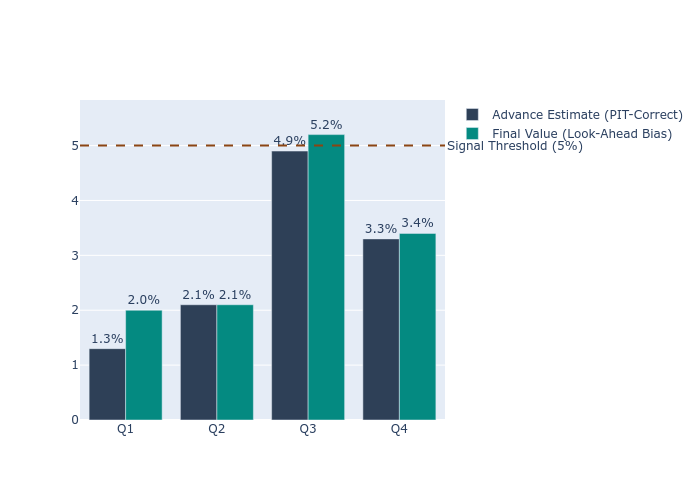

In [12]:
# Visualize the divergence
fig_revision = go.Figure()

fig_revision.add_trace(
    go.Bar(
        name="Advance Estimate (PIT-Correct)",
        x=gdp_revisions["quarter"].to_list(),
        y=gdp_revisions["advance_estimate"].to_list(),
        marker_color="#2E4057",  # ML4T blue
        text=[f"{v:.1f}%" for v in gdp_revisions["advance_estimate"].to_list()],
        textposition="outside",
    )
)

fig_revision.add_trace(
    go.Bar(
        name="Final Value (Look-Ahead Bias)",
        x=gdp_revisions["quarter"].to_list(),
        y=gdp_revisions["final_value"].to_list(),
        marker_color="#048A81",  # Teal
        text=[f"{v:.1f}%" for v in gdp_revisions["final_value"].to_list()],
        textposition="outside",
    )
)

fig_revision.add_hline(
    y=5.0,
    line_dash="dash",
    line_color="#8B4513",
    annotation_text="Signal Threshold (5%)",
    annotation_position="right",
)

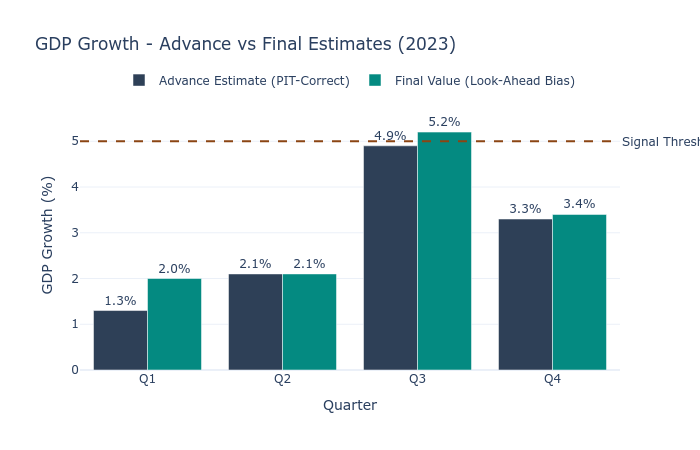

In [13]:
fig_revision.update_layout(
    title="GDP Growth - Advance vs Final Estimates (2023)",
    barmode="group",
    yaxis_title="GDP Growth (%)",
    xaxis_title="Quarter",
    template="plotly_white",
    height=450,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)

fig_revision.show()

## 5. Creating Macro Features

Raw macro values are often non-stationary (trending over time). For ML models, we create
features that are:

- **Stationary**: Changes, growth rates, z-scores
- **Regime-indicative**: Threshold-based classifications
- **Momentum-based**: Recent changes vs longer-term trends

In [14]:
def create_macro_features(df: pl.DataFrame) -> pl.DataFrame:
    """Create trading features from aligned macro data."""
    result = df.clone()

    # Yield Curve Features (T10Y2Y)
    if "t10y2y" in df.columns:
        result = result.with_columns(
            [
                # Level
                pl.col("t10y2y").alias("yield_curve_spread"),
                # Regime classification
                pl.when(pl.col("t10y2y") < 0)
                .then(pl.lit("inverted"))
                .when(pl.col("t10y2y") < 0.5)
                .then(pl.lit("flat"))
                .when(pl.col("t10y2y") < 1.5)
                .then(pl.lit("normal"))
                .otherwise(pl.lit("steep"))
                .alias("yield_curve_regime"),
                # Momentum (20-day change)
                (pl.col("t10y2y") - pl.col("t10y2y").shift(20)).alias("yield_curve_momentum_20d"),
                # Rolling z-score (252-day)
                (
                    (pl.col("t10y2y") - pl.col("t10y2y").rolling_mean(252))
                    / pl.col("t10y2y").rolling_std(252)
                ).alias("yield_curve_zscore_252d"),
            ]
        )

    # VIX Volatility Features
    if "vixcls" in df.columns:
        result = result.with_columns(
            [
                pl.col("vixcls").alias("vix"),
                # Regime classification
                pl.when(pl.col("vixcls") < 15)
                .then(pl.lit("low_vol"))
                .when(pl.col("vixcls") < 25)
                .then(pl.lit("normal_vol"))
                .when(pl.col("vixcls") < 35)
                .then(pl.lit("elevated_vol"))
                .otherwise(pl.lit("high_vol"))
                .alias("volatility_regime"),
                # Momentum (5-day change)
                (pl.col("vixcls") - pl.col("vixcls").shift(5)).alias("vix_momentum_5d"),
                # Rolling z-score (63-day / 3-month)
                (
                    (pl.col("vixcls") - pl.col("vixcls").rolling_mean(63))
                    / pl.col("vixcls").rolling_std(63)
                ).alias("vix_zscore_63d"),
            ]
        )

    # Unemployment Features
    if "unrate" in df.columns:
        result = result.with_columns(
            [
                pl.col("unrate").alias("unemployment_rate"),
                # Regime
                pl.when(pl.col("unrate") < 4.0)
                .then(pl.lit("tight"))
                .when(pl.col("unrate") < 6.0)
                .then(pl.lit("normal"))
                .otherwise(pl.lit("recession"))
                .alias("labor_market_regime"),
                # 1-month change (21 trading days)
                (pl.col("unrate") - pl.col("unrate").shift(21)).alias("unemployment_change_1m"),
                # 12-month change
                (pl.col("unrate") - pl.col("unrate").shift(252)).alias("unemployment_change_1y"),
            ]
        )

    # CPI/Inflation Features
    # Important: CPI is a monthly series in levels. If it's been forward-filled to daily,
    # using shift(252) (trading days) is NOT a true year-over-year calculation.
    # A simple approximation on daily grids is 365 calendar days.
    if "cpiaucsl" in df.columns:
        result = result.with_columns(
            [
                # Year-over-year inflation (365 calendar days for monthly forward-filled data)
                (pl.col("cpiaucsl") / pl.col("cpiaucsl").shift(365) - 1).alias("inflation_yoy"),
                # Inflation regime
                pl.when((pl.col("cpiaucsl") / pl.col("cpiaucsl").shift(365) - 1) < 0.02)
                .then(pl.lit("low"))
                .when((pl.col("cpiaucsl") / pl.col("cpiaucsl").shift(365) - 1) < 0.04)
                .then(pl.lit("moderate"))
                .otherwise(pl.lit("high"))
                .alias("inflation_regime"),
            ]
        )

    # Initial Claims Features
    # Note: If weekly claims have been forward-filled to daily, rolling windows over days
    # are smoothing proxies, not true "4-week averages" over weekly observations.
    if "icsa" in df.columns:
        result = result.with_columns(
            [
                pl.col("icsa").alias("initial_claims"),
                # Smoothing proxy on daily grid; for a true 4-week average, compute on weekly data first.
                pl.col("icsa").rolling_mean(20).alias("claims_smooth_20d"),
                # Regime
                pl.when(pl.col("icsa") < 250000)
                .then(pl.lit("strong"))
                .when(pl.col("icsa") < 350000)
                .then(pl.lit("normal"))
                .otherwise(pl.lit("weak"))
                .alias("claims_regime"),
            ]
        )

    return result


# Create features
macro_features = create_macro_features(pit_df)

# List new features
original_cols = set(macro_df.columns)
feature_cols = [c for c in macro_features.columns if c not in original_cols and c != "timestamp"]

print(f"Created {len(feature_cols)} macro features:")
for col in sorted(feature_cols):
    print(f"  - {col}")

Created 17 macro features:
  - claims_regime
  - claims_smooth_20d
  - inflation_regime
  - inflation_yoy
  - initial_claims
  - labor_market_regime
  - unemployment_change_1m
  - unemployment_change_1y
  - unemployment_rate
  - vix
  - vix_momentum_5d
  - vix_zscore_63d
  - volatility_regime
  - yield_curve_momentum_20d
  - yield_curve_regime
  - yield_curve_spread
  - yield_curve_zscore_252d


In [15]:
# Display sample of macro features
display_cols = ["timestamp", "yield_curve_spread", "yield_curve_regime", "vix", "volatility_regime"]
if "unemployment_rate" in macro_features.columns:
    display_cols.extend(["unemployment_rate", "labor_market_regime"])

macro_features.select([c for c in display_cols if c in macro_features.columns]).tail(10)

timestamp,yield_curve_spread,yield_curve_regime,vix,volatility_regime,unemployment_rate,labor_market_regime
date,f64,str,f64,str,f64,str
2025-12-22,0.73,"""normal""",14.08,"""low_vol""",4.4,"""normal"""
2025-12-23,0.7,"""normal""",14.0,"""low_vol""",4.4,"""normal"""
2025-12-24,0.68,"""normal""",13.47,"""low_vol""",4.4,"""normal"""
2025-12-25,0.68,"""normal""",13.47,"""low_vol""",4.4,"""normal"""
2025-12-26,0.68,"""normal""",13.6,"""low_vol""",4.4,"""normal"""
2025-12-27,0.68,"""normal""",13.6,"""low_vol""",4.4,"""normal"""
2025-12-28,0.68,"""normal""",13.6,"""low_vol""",4.4,"""normal"""
2025-12-29,0.67,"""normal""",14.2,"""low_vol""",4.4,"""normal"""
2025-12-30,0.69,"""normal""",14.33,"""low_vol""",4.4,"""normal"""


## 6. Visualizing Macro Regimes

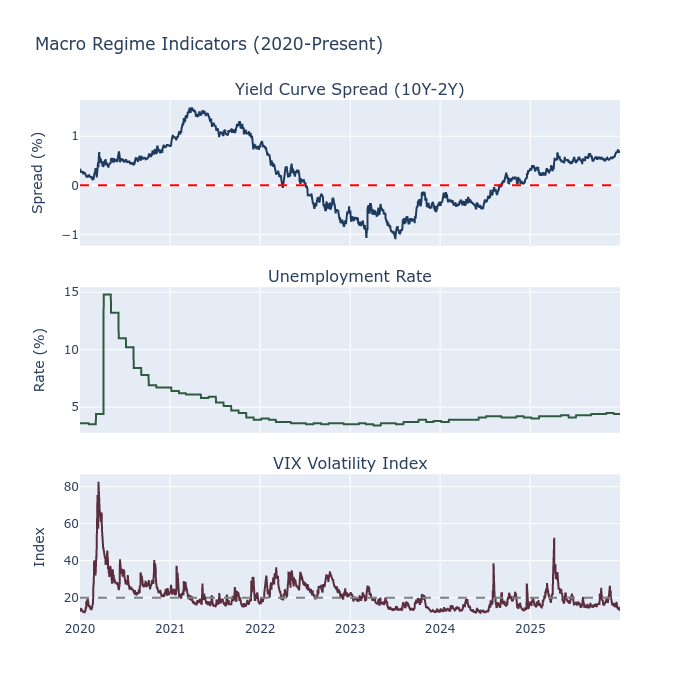

In [16]:
# Prepare data for visualization (2020 onwards for readability)
VIZ_START_DATE = date(2020, 1, 1)

viz_df = (
    macro_features.filter(pl.col("timestamp") >= VIZ_START_DATE)
    .filter(pl.col("yield_curve_spread").is_not_null())
    .to_pandas()
)

# Build the three-panel macro-indicator figure in a SINGLE cell so the
# inline backend cannot capture a yield-curve-only intermediate render
# (feedback_split_cell_figure_bug).
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=("Yield Curve Spread (10Y-2Y)", "Unemployment Rate", "VIX Volatility Index"),
    vertical_spacing=0.08,
)

# Yield curve
fig.add_trace(
    go.Scatter(
        x=viz_df["timestamp"],
        y=viz_df["yield_curve_spread"],
        mode="lines",
        name="10Y-2Y Spread",
        line={"color": "#1E3A5F"},
    ),
    row=1,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=1)

# Unemployment
if "unemployment_rate" in viz_df.columns:
    fig.add_trace(
        go.Scatter(
            x=viz_df["timestamp"],
            y=viz_df["unemployment_rate"],
            mode="lines",
            name="Unemployment",
            line={"color": "#2E5A3F"},
        ),
        row=2,
        col=1,
    )

# VIX
if "vix" in viz_df.columns:
    fig.add_trace(
        go.Scatter(
            x=viz_df["timestamp"],
            y=viz_df["vix"],
            mode="lines",
            name="VIX",
            line={"color": "#5A2E3F"},
        ),
        row=3,
        col=1,
    )
    fig.add_hline(y=20, line_dash="dash", line_color="gray", row=3, col=1)

fig.update_layout(
    height=700,
    title_text="Macro Regime Indicators (2020-Present)",
    showlegend=False,
)
fig.update_yaxes(title_text="Spread (%)", row=1, col=1)
fig.update_yaxes(title_text="Rate (%)", row=2, col=1)
fig.update_yaxes(title_text="Index", row=3, col=1)

fig.show()

## 7. Regime Distribution Analysis

In [17]:
# Analyze regime distributions
print("Regime Distributions (2020+):\n")

regime_cols = [c for c in macro_features.columns if c.endswith("_regime")]
analysis_df = macro_features.filter(pl.col("timestamp") >= VIZ_START_DATE)

for col in regime_cols:
    if col in analysis_df.columns:
        counts = (
            analysis_df.filter(pl.col(col).is_not_null())
            .group_by(col)
            .len()
            .sort("len", descending=True)
        )
        total = counts["len"].sum()
        print(f"{col}:")
        for row in counts.iter_rows():
            pct = 100 * row[1] / total
            print(f"  {row[0]:15s}: {row[1]:>5,} ({pct:>5.1f}%)")
        print()

Regime Distributions (2020+):

yield_curve_regime:
  normal         :   799 ( 36.5%)
  inverted       :   789 ( 36.0%)
  flat           :   574 ( 26.2%)
  steep          :    30 (  1.4%)

volatility_regime:
  normal_vol     : 1,297 ( 59.2%)
  low_vol        :   423 ( 19.3%)
  elevated_vol   :   382 ( 17.4%)
  high_vol       :    90 (  4.1%)

labor_market_regime:
  tight          :   947 ( 43.2%)
  normal         :   850 ( 38.8%)
  recession      :   395 ( 18.0%)

inflation_regime:
  moderate       : 1,035 ( 47.2%)
  high           :   791 ( 36.1%)
  low            :   366 ( 16.7%)

claims_regime:
  strong         : 1,527 ( 69.7%)
  weak           :   539 ( 24.6%)
  normal         :   126 (  5.7%)



## 8. Combining with Price Data

The ultimate goal: use macro features as inputs to trading strategies. The pre-aligned
daily macro data can be joined directly with price data.

In [18]:
def combine_with_prices(
    macro_df: pl.DataFrame, prices_df: pl.DataFrame, date_col: str = "timestamp"
) -> pl.DataFrame:
    """Combine macro features with price data via left join on date."""
    return prices_df.join(macro_df, on=date_col, how="left")


# Load real SPY closes and align to the macro window
price_data = (
    load_etfs(symbols=["SPY"], start_date=str(VIZ_START_DATE))
    .sort("timestamp")
    .with_columns(spy_return=pl.col("close").pct_change())
    .select(timestamp="timestamp", spy_close="close", spy_return="spy_return")
)

# Combine: SPY trading days on the left, daily-aligned macro features attached
combined = combine_with_prices(macro_features, price_data)

cols = ["timestamp", "spy_close", "spy_return", "yield_curve_regime", "volatility_regime"]
if "labor_market_regime" in combined.columns:
    cols.append("labor_market_regime")
combined.select([c for c in cols if c in combined.columns]).tail(10)

timestamp,spy_close,spy_return,yield_curve_regime,volatility_regime,labor_market_regime
date,f64,f64,str,str,str
2025-12-17,667.598694,-0.011004,"""normal""","""normal_vol""","""normal"""
2025-12-18,672.639954,0.007551,"""normal""","""normal_vol""","""normal"""
2025-12-19,678.736389,0.009063,"""normal""","""low_vol""","""normal"""
2025-12-22,682.964844,0.00623,"""normal""","""low_vol""","""normal"""
2025-12-23,686.086304,0.00457,"""normal""","""low_vol""","""normal"""
2025-12-24,688.499695,0.003518,"""normal""","""low_vol""","""normal"""
2025-12-26,688.429871,-0.000101,"""normal""","""low_vol""","""normal"""
2025-12-29,685.976562,-0.003564,"""normal""","""low_vol""","""normal"""
2025-12-30,685.138916,-0.001221,"""normal""","""low_vol""","""normal"""


## 9. Key Takeaways

| Concept | Implementation |
|---------|---------------|
| **Point-in-Time** | Apply release lag; use ALFRED vintage queries for historical accuracy |
| **Frequency Alignment** | Pre-download handles forward-fill; apply additional lag for release delay |
| **Stationarity** | Transform levels to changes, growth rates, and z-scores |
| **Regimes** | Threshold-based classifications for interpretable signals |

**Common Pitfalls**:
- Using observation date instead of release date → look-ahead bias
- Using final revised values instead of vintage data → look-ahead bias
- Raw levels instead of stationary transforms → spurious correlations
- Ignoring release calendar → using information before it's public